# Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# EDA

In [3]:
df = pd.read_csv('data/wine-clustering.csv')

In [4]:
df.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


## Mengetahui Informasi pada Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


## Membuat Scatterplot

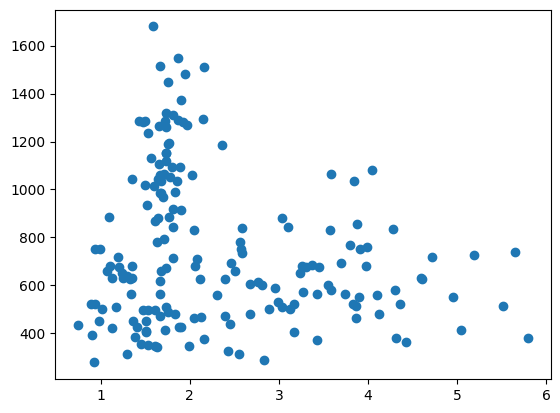

In [6]:
x_axis=df.loc[:,['Malic_Acid']]
y_axis=df.loc[:,['Proline']]
plt.scatter(x_axis,y_axis)

# Model Machine Learning

## K-Means Clustering

In [7]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit(df)

KMeans(n_clusters=3)

In [8]:
pred = kmeans.predict(df)

In [9]:
pred

array([1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 0, 2,
       0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0], dtype=int32)

## Membuat Scatterplot dari hasil K-Means

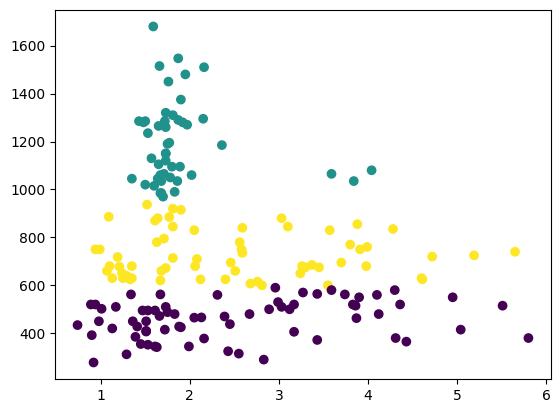

In [10]:
plt.scatter(x_axis, y_axis, c=pred)

## Menentukan Jumlah Cluster Optimal dalam K-Means Clustering, Menggunakan Metode Elbow

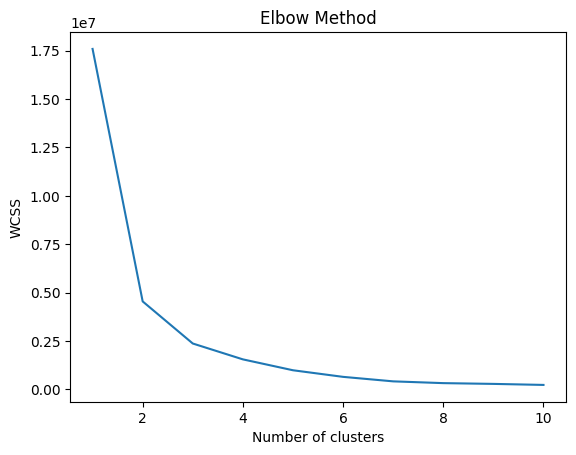

In [11]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,max_iter=300,random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Deep Scan

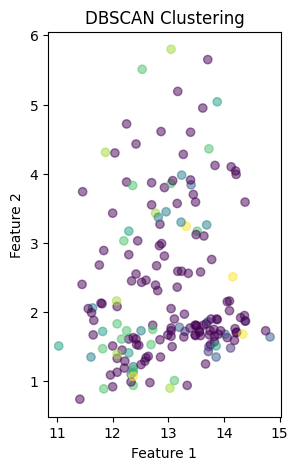

In [12]:
dbscan = DBSCAN(eps=11, min_samples=4)
dbscan_labels = dbscan.fit_predict(df)

# visualisasi dbscan clustering
plt.figure(figsize=(3, 5))

plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dbscan_labels, cmap="viridis", alpha=0.5)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [13]:
dbscan_labels

array([-1,  1, -1, -1, -1, -1,  0, -1,  1,  1, -1,  0, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  0, -1,  1,  0, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  1, -1,  2, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  0,  4,  2, -1, -1,  3, -1,  2,  4,  4,
       -1, -1, -1,  3, -1, -1, -1, -1,  5, -1, -1, -1, -1, -1, -1,  4,  4,
       -1,  4, -1,  2, -1,  4, -1,  4, -1, -1, -1, -1,  3,  6,  3, -1, -1,
       -1,  3,  2, -1,  4,  4, -1,  2, -1, -1, -1, -1,  5,  3,  4, -1,  5,
       -1, -1, -1, -1,  5,  5,  5, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  4, -1, -1, -1, -1,  4, -1, -1, -1,  3, -1,  6, -1, -1, -1, -1,
        2, -1, -1, -1, -1,  6, -1,  4,  2, -1,  2, -1,  4, -1,  2, -1, -1,
        4, -1,  6, -1, -1, -1, -1, -1])

# PCA (Principal Component Analysis)

In [14]:
x = df
y = dbscan.fit_predict(df)

In [15]:
pca = PCA(n_components=3) # mengatur jumlah komponen yang dibutuhkan

# fit dan mengubah data
x_pca = pca.fit_transform(x)

In [16]:
# membuat dataframe dengan hasil PCA
pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2','PC3'])

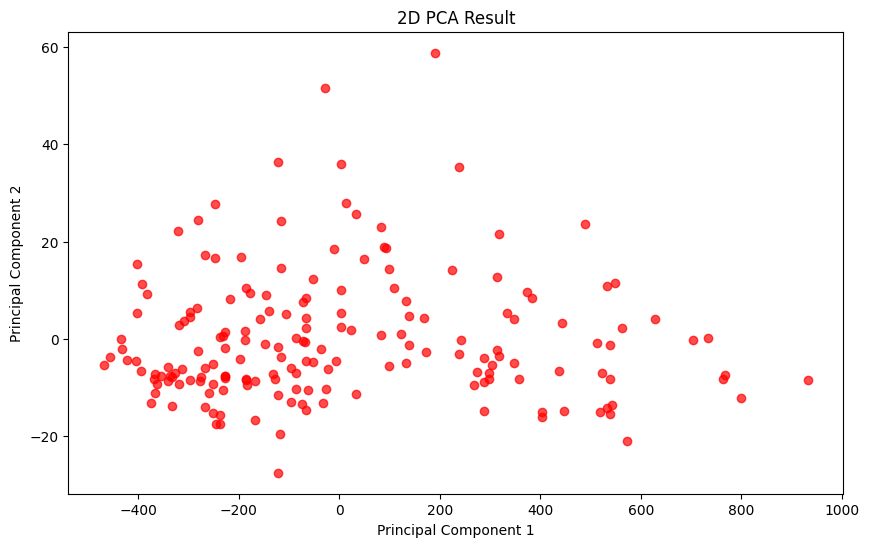

In [17]:
import matplotlib.pyplot as plt

# Membuat scatter plot 2D
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7, c='red')

# Menambahkan label dan title
plt.title('2D PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()


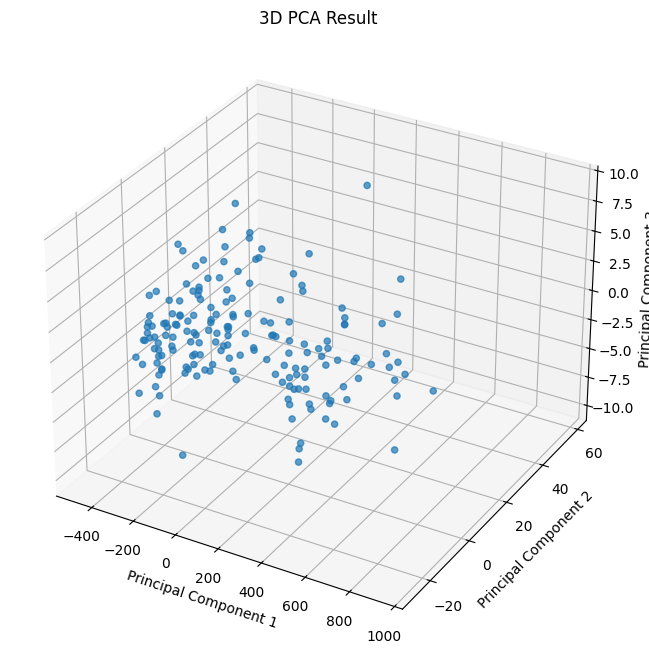

In [18]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# membuat scatter plot
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], alpha=0.7)

# Set labels and title
ax.set_title('3D PCA Result')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.show()

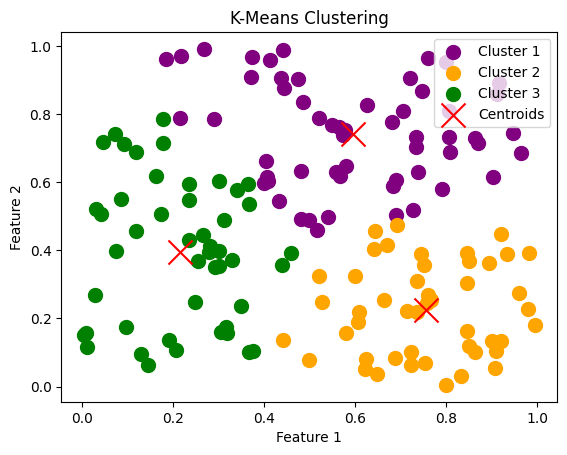

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Contoh data (gantilah dengan dataset aslimu)
x = np.random.rand(150, 2)  # 150 data dengan 2 fitur

# Menjalankan K-Means
kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(x)

# Visualisasi cluster
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s=100, c='purple', label='Cluster 1')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s=100, c='orange', label='Cluster 2')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='x', label='Centroids')

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


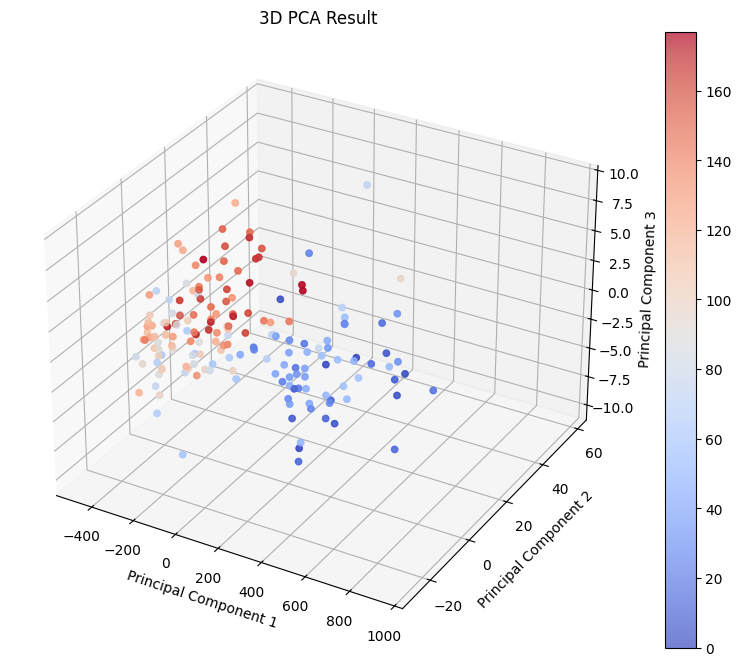

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Menambahkan warna berdasarkan indeks baris dataset
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=range(len(pca_df)), cmap='coolwarm', alpha=0.7)

# Set labels and title
ax.set_title('3D PCA Result')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.colorbar(ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=range(len(pca_df)), cmap='coolwarm', alpha=0.7))
plt.show()
